# 02 · The Mathematics of Neural Networks

*Companion notebook for the chapter* **The Mathematics of Neural Networks**

Before making a network Bayesian we build an ordinary one **from scratch in NumPy** — no deep-learning library — so that every weight, sum and derivative is visible.

**Contents**
1. Structure of a neural network
2. Weights and linear combinations
3. Activation functions
4. Matrix multiplication: a whole layer at once
5. Training with gradient descent and backpropagation
6. How much data do you need?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

## 1–2. One neuron: weights and a linear combination

A neuron takes inputs $x_1,\dots,x_d$, multiplies each by a **weight** $w_i$, adds a **bias** $b$ and applies an **activation** $\phi$:

$$z = \sum_{i=1}^d w_i x_i + b = \mathbf w^\top\mathbf x + b,\qquad a=\phi(z)$$

The weights are the numbers that training adjusts. In a BNN each $w_i$ will become a *probability distribution* instead of a single number.

In [2]:
x = np.array([0.5, -1.2, 3.0])      # three input features
w = np.array([0.8, 0.1, -0.4])      # three weights
b = 0.2

z = w @ x + b
print("z = w·x + b =", z)
print("sigmoid(z) =", 1 / (1 + np.exp(-z)))

z = w·x + b = -0.72
sigmoid(z) = 0.32739298293223956


## 3. Activation functions

Without a nonlinearity $\phi$, stacking layers would still give a linear function. Common choices:

| name | formula | derivative |
|---|---|---|
| sigmoid | $\sigma(z)=\frac1{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ |
| tanh | $\tanh z$ | $1-\tanh^2 z$ |
| ReLU | $\max(0,z)$ | $\mathbb 1[z>0]$ |
| softplus | $\log(1+e^z)$ | $\sigma(z)$ |

(Softplus reappears in notebook 06, where it keeps standard deviations positive.)

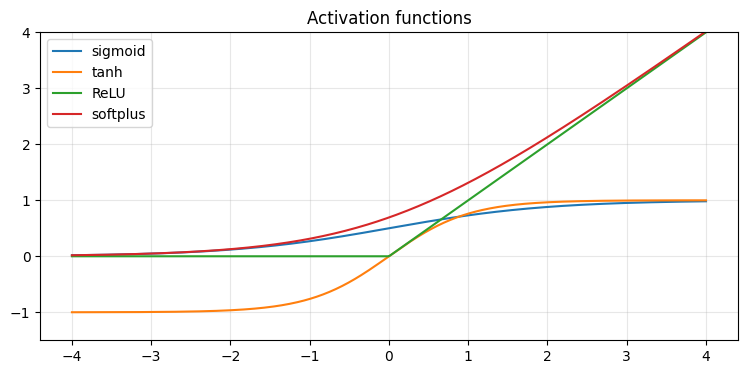

In [3]:
z = np.linspace(-4, 4, 400)
acts = {
    "sigmoid": 1 / (1 + np.exp(-z)),
    "tanh": np.tanh(z),
    "ReLU": np.maximum(0, z),
    "softplus": np.log1p(np.exp(z)),
}
for name, a in acts.items():
    plt.plot(z, a, label=name)
plt.ylim(-1.5, 4); plt.legend(); plt.title("Activation functions"); plt.show()

## 4. Matrix multiplication: a layer and a batch at once

A layer with $h$ neurons has a weight matrix $W\in\mathbb R^{d\times h}$ and bias $\mathbf b\in\mathbb R^h$. For a batch of $n$ inputs stacked as rows of $X\in\mathbb R^{n\times d}$:

$$H=\phi(XW_1+\mathbf b_1)\in\mathbb R^{n\times h},\qquad \hat{\mathbf y}=HW_2+\mathbf b_2$$

Keeping track of **shapes** is the most useful debugging habit in deep learning.

In [4]:
n, d, h = 5, 3, 4
X  = rng.standard_normal((n, d))
W1 = rng.standard_normal((d, h)); b1 = np.zeros(h)
W2 = rng.standard_normal((h, 1)); b2 = np.zeros(1)

H = np.tanh(X @ W1 + b1)
y_hat = H @ W2 + b2
print("X:", X.shape, " W1:", W1.shape, " H:", H.shape, " W2:", W2.shape, " y_hat:", y_hat.shape)

# the same thing, neuron by neuron, to see that matrix multiplication is just many dot products
H_loop = np.array([[np.tanh(X[i] @ W1[:, j] + b1[j]) for j in range(h)] for i in range(n)])
print("loop == matrix version:", np.allclose(H, H_loop))

X: (5, 3)  W1: (3, 4)  H: (5, 4)  W2: (4, 1)  y_hat: (5, 1)
loop == matrix version: True


## 5. How neural networks are trained

Training minimises a **loss**. For regression, the mean squared error

$$L(\mathbf w)=\frac1n\sum_{i=1}^n\big(y_i-\hat y_i(\mathbf w)\big)^2 .$$

**Gradient descent** repeats $\mathbf w\leftarrow\mathbf w-\eta\,\nabla_{\mathbf w}L$. **Backpropagation** is the chain rule applied layer by layer, from the output back to the input:

$$\frac{\partial L}{\partial W_2}=H^\top\delta_2,\quad \delta_2=\frac{2}{n}(\hat{\mathbf y}-\mathbf y),\qquad
\frac{\partial L}{\partial W_1}=X^\top\delta_1,\quad \delta_1=(\delta_2W_2^\top)\odot(1-H^2)$$

(The factor $1-H^2$ is the derivative of tanh.)

In [5]:
class TinyMLP:
    def __init__(self, d_in, d_hidden, seed=0):
        r = np.random.default_rng(seed)
        self.W1 = r.normal(0, 1 / np.sqrt(d_in), (d_in, d_hidden)); self.b1 = r.uniform(-3, 3, d_hidden)   # spread the "kinks" over the input range
        self.W2 = r.normal(0, 1 / np.sqrt(d_hidden), (d_hidden, 1)); self.b2 = np.zeros(1)

    def forward(self, X):
        self.X = X
        self.H = np.tanh(X @ self.W1 + self.b1)
        return (self.H @ self.W2 + self.b2).ravel()

    def backward(self, y_hat, y):
        n = len(y)
        d2 = (2 / n) * (y_hat - y)[:, None]            # dL/d y_hat
        gW2 = self.H.T @ d2; gb2 = d2.sum(0)
        d1 = (d2 @ self.W2.T) * (1 - self.H**2)       # back through tanh
        gW1 = self.X.T @ d1; gb1 = d1.sum(0)
        return gW1, gb1, gW2, gb2

    def step(self, grads, lr):
        for p, g in zip([self.W1, self.b1, self.W2, self.b2], grads):
            p -= lr * g

    def n_params(self):
        return sum(p.size for p in [self.W1, self.b1, self.W2, self.b2])

### Gradient check
Before trusting backprop, compare it with a finite-difference estimate $\frac{L(w+\epsilon)-L(w-\epsilon)}{2\epsilon}$.

In [6]:
net = TinyMLP(1, 8)
Xc = rng.uniform(-2, 2, (20, 1)); yc = np.sin(2 * Xc).ravel()
loss = lambda: np.mean((net.forward(Xc) - yc) ** 2)

gW1 = net.backward(net.forward(Xc), yc)[0]
eps = 1e-6
net.W1[0, 3] += eps; lp = loss()
net.W1[0, 3] -= 2 * eps; lm = loss()
net.W1[0, 3] += eps
print(f"backprop: {gW1[0, 3]:.8f}   finite difference: {(lp - lm) / (2 * eps):.8f}")

backprop: -0.00579470   finite difference: -0.00579470


### Train on a noisy sine curve

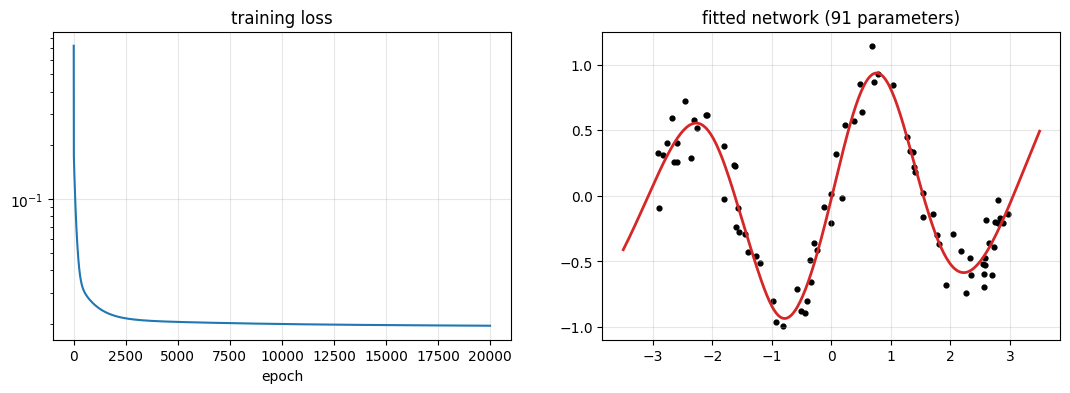

In [7]:
def make_data(n, noise=0.15):
    X = rng.uniform(-3, 3, (n, 1))
    return X, np.sin(2 * X).ravel() * np.exp(-0.1 * X.ravel()**2) + noise * rng.standard_normal(n)

X_train, y_train = make_data(80)
net = TinyMLP(1, 30, seed=1)
losses = []
for epoch in range(20000):
    y_hat = net.forward(X_train)
    losses.append(np.mean((y_hat - y_train) ** 2))
    net.step(net.backward(y_hat, y_train), lr=0.05)

xg = np.linspace(-3.5, 3.5, 300)[:, None]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(losses); ax[0].set_yscale("log"); ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
ax[1].scatter(X_train, y_train, s=12, c="k"); ax[1].plot(xg, net.forward(xg), c="C3", lw=2)
ax[1].set_title(f"fitted network ({net.n_params()} parameters)")
plt.show()

## 6. How much data do you need?

A network with $p$ parameters can memorise a small data set. The gap between **training** and **test** error shows it.
A rough rule of thumb is to have many more examples than parameters — but priors (notebook 03) and Bayesian averaging (04–08) make small-data problems much safer.

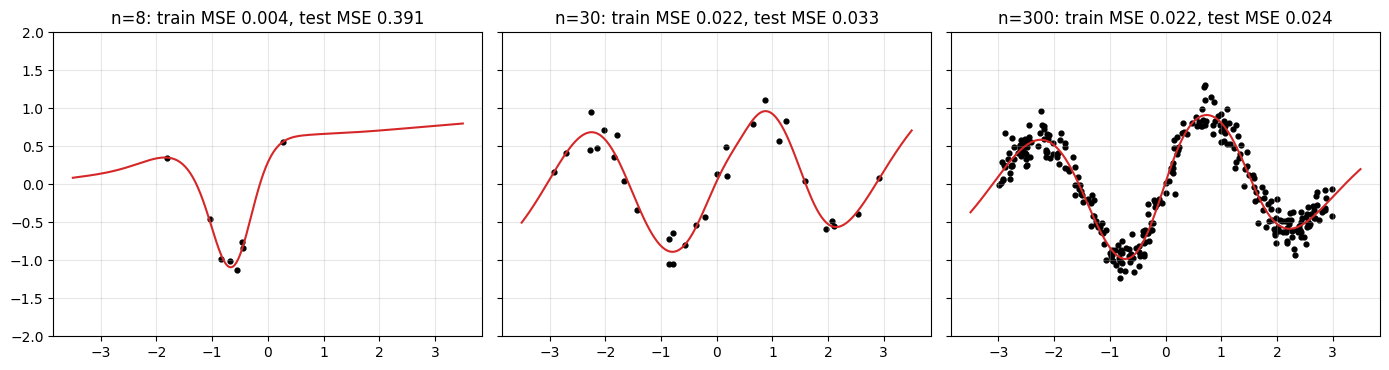

In [8]:
X_test, y_test = make_data(1000)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, n in zip(axes, [8, 30, 300]):
    Xn, yn = make_data(n)
    m = TinyMLP(1, 30, seed=2)
    for _ in range(8000):
        m.step(m.backward(m.forward(Xn), yn), lr=0.05)
    tr = np.mean((m.forward(Xn) - yn) ** 2); te = np.mean((m.forward(X_test) - y_test) ** 2)
    ax.scatter(Xn, yn, s=12, c="k"); ax.plot(xg, m.forward(xg), c="C3")
    ax.set_title(f"n={n}: train MSE {tr:.3f}, test MSE {te:.3f}"); ax.set_ylim(-2, 2)
plt.tight_layout(); plt.show()

With 8 points the network fits the training data almost perfectly and still generalises poorly — and, crucially, **it gives no signal that it is unreliable**. That is exactly what BNNs fix.

## Exercises
1. Replace `tanh` with ReLU in `TinyMLP` (you must also change the derivative in `backward`).
2. Add a second hidden layer. Write down the new backprop equations first.
3. Add an L2 penalty $\lambda\lVert\mathbf w\rVert^2$ to the loss. What changes in the gradient? (Notebook 03 shows this is a Gaussian prior in disguise.)